In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Train/Test Split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (455, 30)
Test size: (114, 30)


# Training Classification Tree

In [3]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


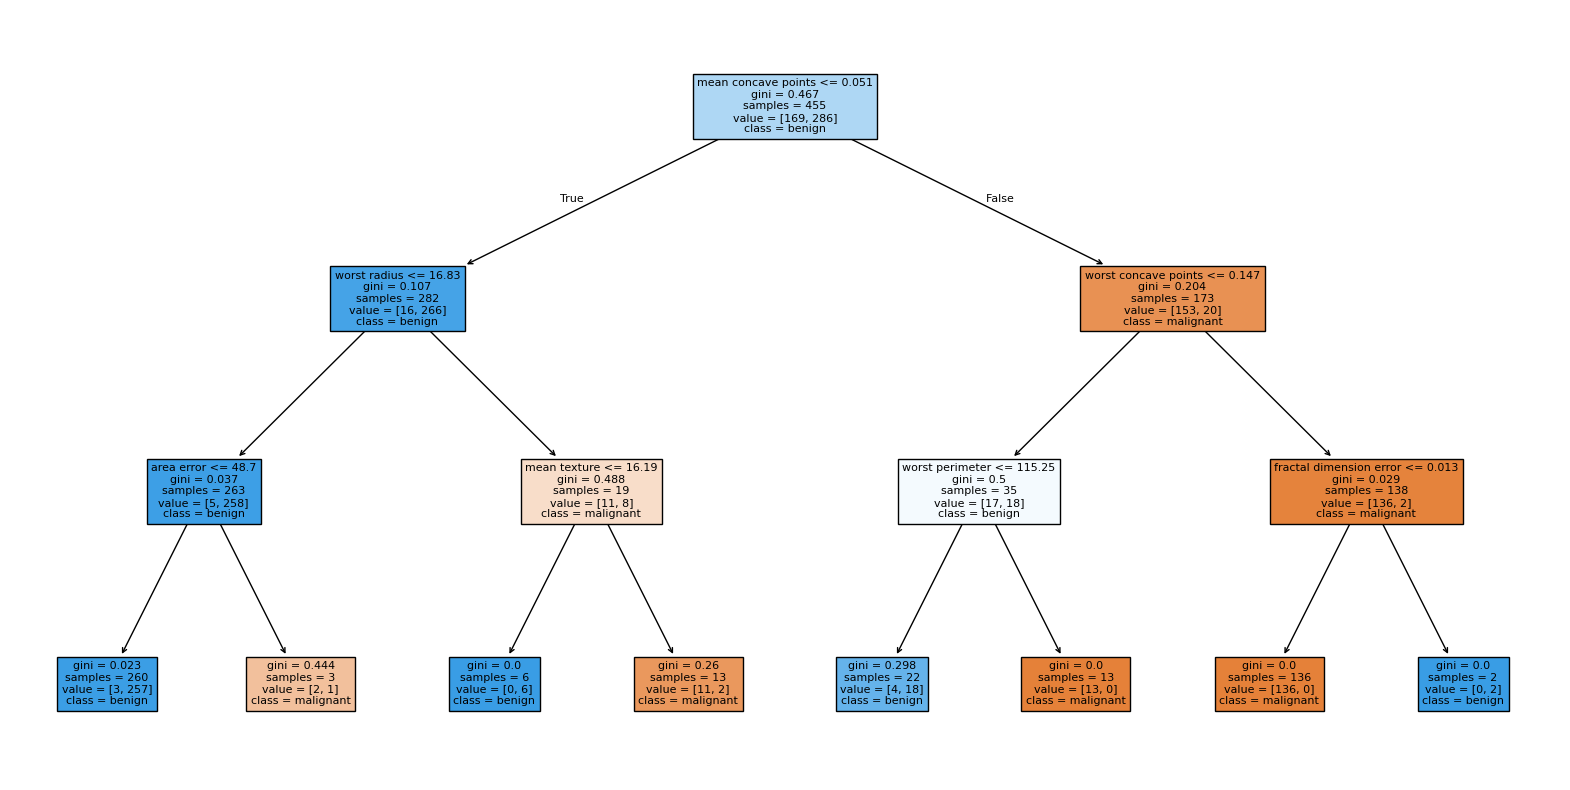

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=['malignant', 'benign'],
          filled=True)
plt.show()

### How the Tree Partitions the Predictor Space

The classification tree partitions the predictor space using a series of binary splits based on the most important features. The first split occurs on **mean concave points**, indicating that this is the most influential variable in distinguishing between malignant and benign tumors.

Observations with lower values of mean concave points are classified into one branch (mostly benign cases), while higher values lead to another branch (mostly malignant cases). This shows that tumors with more irregular cell shapes tend to be malignant.

Further splits occur on variables such as **worst radius, area error, texture**, and **fractal dimension**, which refine the classification into smaller and more homogeneous groups. Each split creates regions in the feature space where observations share similar characteristics.

Each terminal node (leaf) represents a final decision region where the model assigns a class label (malignant or benign) based on the majority class of training samples in that region.

For example, tumors with low concave points and smaller radius tend to be classified as benign, while those with high concave points and larger radius are more likely to be classified as malignant.

Overall, the tree creates clear decision boundaries that group patients into meaningful categories based on their tumor characteristics, allowing for interpretable and rule-based predictions.

Each terminal node assigns a class label (benign or malignant) based on the majority class of observations in that region. The proportion of samples in each node can also be interpreted as the probability of belonging to each class.

# Analyzing Overfitting (Classification Tree)

In [6]:
from sklearn.metrics import accuracy_score

# Predictions
y_train_pred = tree_model.predict(X_train)
y_test_pred = tree_model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.978021978021978
Test Accuracy: 0.9473684210526315


### Analyze Overfitting

The classification tree shows a slight indication of overfitting when comparing training and test accuracy.

The training accuracy (approximately 97.8%) is higher than the test accuracy (approximately 94.7%), indicating that the model fits the training data better than unseen data. However, the difference is small, suggesting good generalization.

This reflects mild overfitting rather than severe overfitting. The model captures important patterns while maintaining strong predictive performance.

The misclassification error (1 − accuracy) is slightly higher on the test set than the training set, further confirming mild overfitting.

To improve generalization, cost-complexity pruning can be applied to simplify the tree.

# Cost-Complexity Pruning

In [8]:
# Training a full tree
from sklearn.tree import DecisionTreeClassifier

full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

print("Full tree depth:", full_tree.get_depth())
print("Full tree terminal nodes:", full_tree.get_n_leaves())

Full tree depth: 7
Full tree terminal nodes: 16


In [9]:
# ccp_alpha values
path = full_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Number of alphas:", len(ccp_alphas))

Number of alphas: 13


In [10]:
# Train trees for different ccp_alpha
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    trees.append(model)

print("Number of trees trained:", len(trees))

Number of trees trained: 13


In [11]:
# Comparing train vs test error
train_errors = []
test_errors = []

for model in trees:
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_errors.append(1 - accuracy_score(y_train, train_pred))
    test_errors.append(1 - accuracy_score(y_test, test_pred))

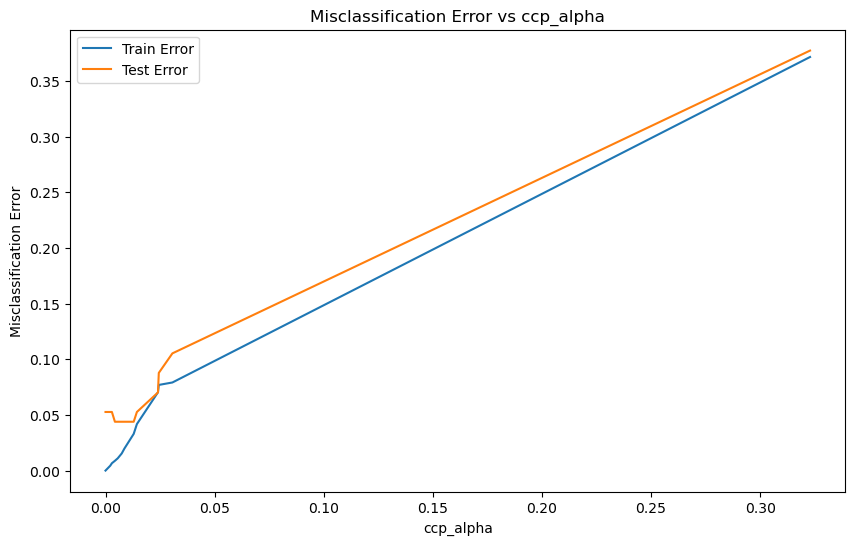

In [12]:
# Plotting error vs ccp_alpha
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(ccp_alphas, train_errors, label="Train Error")
plt.plot(ccp_alphas, test_errors, label="Test Error")
plt.xlabel("ccp_alpha")
plt.ylabel("Misclassification Error")
plt.title("Misclassification Error vs ccp_alpha")
plt.legend()
plt.show()

In [14]:
# Finding best alpha
best_index = np.argmin(test_errors)
best_alpha = ccp_alphas[best_index]

print("Best ccp_alpha:", best_alpha)
print("Lowest Test Error:", test_errors[best_index])

Best ccp_alpha: 0.004311334641004935
Lowest Test Error: 0.04385964912280704


In [15]:
# Trainning optimal pruned tree
optimal_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

optimal_tree.fit(X_train, y_train)

print("Optimal tree depth:", optimal_tree.get_depth())
print("Optimal terminal nodes:", optimal_tree.get_n_leaves())

Optimal tree depth: 4
Optimal terminal nodes: 10


### Cost-Complexity Pruning

Cost-complexity pruning was applied to control the complexity of the classification tree using the parameter ccp_alpha.

A sequence of trees was generated for different values of ccp_alpha, and their misclassification errors were evaluated on both the training and test datasets. The results show that the lowest test error (approximately 4.39%) occurs at a small ccp_alpha value (around 0.0043), indicating that only slight pruning is needed.

The optimal pruned tree has a reduced depth of 4 and 10 terminal nodes, compared to the full tree, making it simpler and more interpretable while maintaining strong predictive performance.

As ccp_alpha increases further, both training and test errors increase, suggesting that excessive pruning leads to underfitting by removing important structure from the model.

Overall, the results demonstrate that a lightly pruned tree achieves the best balance between model complexity and generalization.

In [16]:
# Cross-Validation for the Model Selection
from sklearn.model_selection import cross_val_score

cv_errors = []
terminal_nodes = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    # Convert accuracy → error
    cv_errors.append(1 - scores.mean())
    
    model.fit(X_train, y_train)
    terminal_nodes.append(model.get_n_leaves())

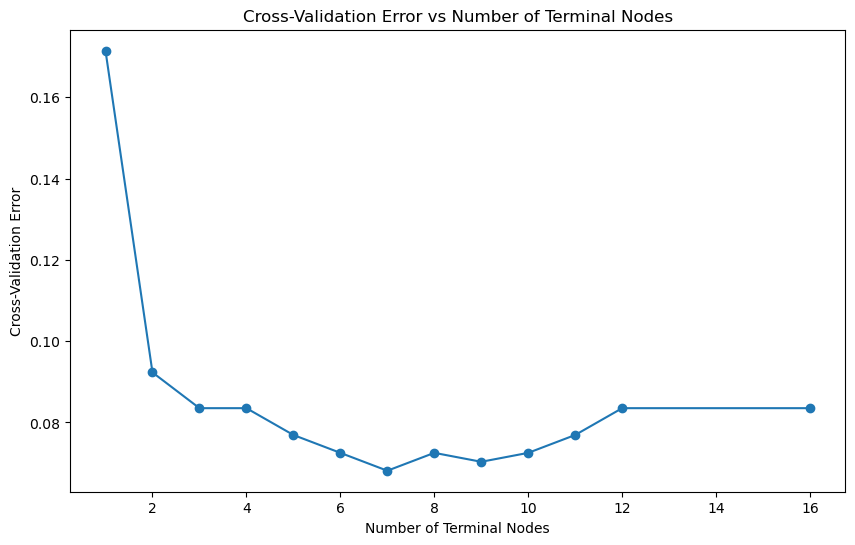

In [18]:
# Plotting CV error vs tree size
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(terminal_nodes, cv_errors, marker="o")
plt.xlabel("Number of Terminal Nodes")
plt.ylabel("Cross-Validation Error")
plt.title("Cross-Validation Error vs Number of Terminal Nodes")
plt.show()

In [19]:
# Finding optimal tree size
best_cv_index = np.argmin(cv_errors)

best_cv_alpha = ccp_alphas[best_cv_index]
best_cv_nodes = terminal_nodes[best_cv_index]
best_cv_error = cv_errors[best_cv_index]

print("Best CV alpha:", best_cv_alpha)
print("Optimal terminal nodes (CV):", best_cv_nodes)
print("Lowest CV error:", best_cv_error)

Best CV alpha: 0.008663799968147794
Optimal terminal nodes (CV): 7
Lowest CV error: 0.06813186813186811


### Cross-Validation for Model Selection

To further validate the model, 5-fold cross-validation was performed across different values of the cost-complexity parameter (ccp_alpha).

The cross-validation error was computed for each pruned tree and plotted against the number of terminal nodes. The results show that the optimal tree corresponds to the model with approximately 7 terminal nodes, which achieves the lowest cross-validation error (about 6.8%).

This indicates that a moderately pruned tree provides the best balance between model complexity and predictive performance. Trees with too many terminal nodes tend to overfit, while those with too few nodes tend to underfit.

Overall, cross-validation confirms that a smaller, well-pruned tree improves generalization performance.

### Final Answers

1. **Optimal number of terminal nodes:**
The optimal classification tree has approximately 7 terminal nodes based on cross-validation results.

2. **Does pruning improve performance?**  
Yes. Pruning improves performance by reducing overfitting. A slightly pruned tree achieves lower test and cross-validation errors compared to the fully grown tree.

3. **Bias-Variance Trade-off:**  
The fully grown tree has low bias but high variance, as it fits the training data very closely but performs worse on unseen data. Pruning increases bias slightly but significantly reduces variance, leading to better generalization. The optimal pruned tree achieves a good balance between bias and variance.